In [1]:
import numpy as np
import pandas as pd
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow warnings
import time
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
sns.set_style('darkgrid')
import shutil
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import tensorflow.keras.applications.efficientnet as efficientnet

2025-08-17 17:31:14.044519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755451874.231245      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755451874.290968      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Set a global random seed for reproducibility
np.random.seed(123)
tf.random.set_seed(123)

In [3]:

train_path = r'/kaggle/input/knee-osteoarthritis-dataset-with-severity/train'
test_path = r'/kaggle/input/knee-osteoarthritis-dataset-with-severity/test'
valid_path = r'/kaggle/input/knee-osteoarthritis-dataset-with-severity/val'
# List of all five classes
list_of_classes = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']
# Create DataFrames for train, test, and validation sets
filepaths = []
labels = []
for d in [train_path, test_path, valid_path]:
    classlist = os.listdir(d)
    for klass in classlist:
        intklass = int(klass)  # Folder names are '0', '1', etc.
        label = list_of_classes[intklass]  # Map to class names
        classpath = os.path.join(d, klass)
        flist = os.listdir(classpath)
        for f in flist:
            fpath = os.path.join(classpath, f)
            filepaths.append(fpath)
            labels.append(label)
    Fseries = pd.Series(filepaths, name='filepaths')
    Lseries = pd.Series(labels, name='labels')
    pdf = pd.concat([Fseries, Lseries], axis=1)
    if d == test_path:
        test_df = pdf
    elif d == valid_path:
        valid_df = pdf
    else:
        train_df = pdf

# Print dataset sizes
print('train_df length:', len(train_df), ' test_df length:', len(test_df), ' valid_df length:', len(valid_df))

# Print number of classes and image counts per class in train_df
classes = sorted(list(train_df['labels'].unique()))
class_count = len(classes)
print('The number of classes in the dataset is:', class_count)
groups = train_df.groupby('labels')
print('{0:^30s} {1:^13s}'.format('CLASS', 'IMAGE COUNT'))
for label in classes:
    group = groups.get_group(label)
    print('{0:^30s} {1:^13s}'.format(label, str(len(group))))

# Calculate average image dimensions
train_df_sample = train_df.sample(n=100, random_state=123)
ht, wt = 0, 0
for i in range(len(train_df_sample)):
    fpath = train_df_sample['filepaths'].iloc[i]
    img = plt.imread(fpath)
    shape = img.shape
    ht += shape[0]
    wt += shape[1]
print('average height=', ht//100, ' average width=', wt//100, 'aspect ratio=', ht/wt)

train_df length: 5778  test_df length: 7434  valid_df length: 8260
The number of classes in the dataset is: 5
            CLASS               IMAGE COUNT 
           Doubtful                1046     
           Healthy                 2286     
           Minimal                 1516     
           Moderate                 757     
            Severe                  173     
average height= 224  average width= 224 aspect ratio= 1.0


In [4]:
drop_classes = ['Minimal', 'Doubtful']

train_df = train_df[~train_df['labels'].isin(drop_classes)]
valid_df = valid_df[~valid_df['labels'].isin(drop_classes)]  
test_df = test_df[~test_df['labels'].isin(drop_classes)]

# Update the list of classes 
list_of_classes = [c for c in list_of_classes if c not in drop_classes]

# Re-calculate the total classes
class_count = len(list_of_classes)

# Re-count the images per class
groups = train_df.groupby('labels')  
for label in list_of_classes:
    group = groups.get_group(label) 
    print(label, len(group))

Healthy 2286
Moderate 757
Severe 173


In [5]:
# Function to trim DataFrame to a maximum number of samples per class
def trim(df, max_samples, min_samples, column):
    df = df.copy()
    trimmed_df = pd.DataFrame(columns=df.columns)
    groups = df.groupby(column)
    for label in df[column].unique():
        group = groups.get_group(label)
        count = len(group)
        if count > max_samples:
            sampled_group = group.sample(n=max_samples, random_state=123)
            trimmed_df = pd.concat([trimmed_df, sampled_group], axis=0)
        elif count >= min_samples:
            trimmed_df = pd.concat([trimmed_df, group], axis=0)
    print('after trimming, max samples per class:', max_samples, ' min samples:', min_samples)
    return trimmed_df

# Trim train_df to balance classes (max 1000 samples to retain more data)
max_samples = 1000  # Increased from 500 to retain more data
min_samples = 173   # Based on smallest class (Severe)
train_df = trim(train_df, max_samples, min_samples, 'labels')

after trimming, max samples per class: 1000  min samples: 173


In [6]:

# Function to balance DataFrame by augmenting underrepresented classes
def balance(df, n, working_dir, img_size):
    df = df.copy()
    print('Initial length of dataframe is', len(df))
    aug_dir = os.path.join(working_dir, 'aug')
    if os.path.isdir(aug_dir):
        shutil.rmtree(aug_dir)
    os.mkdir(aug_dir)
    for label in df['labels'].unique():
        os.mkdir(os.path.join(aug_dir, label))
    
    # Create augmented images
    total = 0
    gen = ImageDataGenerator(
        horizontal_flip=True,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        preprocessing_function=efficientnet.preprocess_input  # Add EfficientNet preprocessing
    )
    groups = df.groupby('labels')
    for label in df['labels'].unique():
        group = groups.get_group(label)
        sample_count = len(group)
        if sample_count < n:
            aug_img_count = 0
            delta = n - sample_count
            target_dir = os.path.join(aug_dir, label)
            print(f'Creating {delta} augmented images for class {label}')
            aug_gen = gen.flow_from_dataframe(
                group,
                x_col='filepaths',
                y_col=None,
                target_size=img_size,
                class_mode=None,
                batch_size=1,
                shuffle=False,
                save_to_dir=target_dir,
                save_prefix='aug-',
                color_mode='rgb',
                save_format='jpg'
            )
            while aug_img_count < delta:
                images = next(aug_gen)
                aug_img_count += len(images)
            total += aug_img_count
    print('Total augmented images created=', total)
    
    # Create augmented DataFrame
    aug_fpaths, aug_labels = [], []
    classlist = os.listdir(aug_dir)
    for klass in classlist:
        classpath = os.path.join(aug_dir, klass)
        flist = os.listdir(classpath)
        for f in flist:
            fpath = os.path.join(classpath, f)
            aug_fpaths.append(fpath)
            aug_labels.append(klass)
    Fseries = pd.Series(aug_fpaths, name='filepaths')
    Lseries = pd.Series(aug_labels, name='labels')
    aug_df = pd.concat([Fseries, Lseries], axis=1)
    df = pd.concat([df, aug_df], axis=0).reset_index(drop=True)
    print('Length of augmented dataframe is now', len(df))
    return df

# Balance train_df to 1000 samples per class
n = 1000  # Target samples per class
working_dir = r'./'
img_size = (224, 224)
train_df = balance(train_df, n, working_dir, img_size)


Initial length of dataframe is 1930
Creating 243 augmented images for class Moderate
Found 757 validated image filenames.
Creating 827 augmented images for class Severe
Found 173 validated image filenames.
Total augmented images created= 1070
Length of augmented dataframe is now 3000


In [7]:
# Custom callback for learning rate adjustment
class LR_ASK(keras.callbacks.Callback):
    def __init__(self, model, epochs, ask_epoch):
        super(LR_ASK, self).__init__()
        self.model = model
        self.ask_epoch = ask_epoch
        self.epochs = epochs
        self.ask = True
        self.lowest_vloss = np.inf
        self.best_weights = self.model.get_weights()
        self.best_epoch = 1
    
    def on_train_begin(self, logs=None):
        if self.ask_epoch == 0:
            print('ask_epoch = 0, setting to 1')
            self.ask_epoch = 1
        if self.ask_epoch >= self.epochs:
            print(f'ask_epoch >= epochs, will train for {self.epochs} epochs')
            self.ask = False
        if self.epochs == 1:
            self.ask = False
        else:
            print(f'Training until epoch {self.ask_epoch}, then you can halt or continue')
        self.start_time = time.time()
    
    def on_train_end(self, logs=None):
        print(f'Loading model with weights from epoch {self.best_epoch}')
        self.model.set_weights(self.best_weights)
        tr_duration = time.time() - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))
        print(f'Training time: {hours} hours, {minutes:.1f} minutes, {seconds:.2f} seconds')
    
    def on_epoch_end(self, epoch, logs=None):
        v_loss = logs.get('val_loss')
        if v_loss < self.lowest_vloss:
            self.lowest_vloss = v_loss
            self.best_weights = self.model.get_weights()
            self.best_epoch = epoch + 1
            print(f'\nValidation loss {v_loss:.4f} is best, saving weights from epoch {epoch + 1}')
        else:
            print(f'\nValidation loss {v_loss:.4f} is above best {self.lowest_vloss:.4f}, keeping weights from epoch {self.best_epoch}')
        
        if self.ask and epoch + 1 == self.ask_epoch:
            print('\nEnter H to halt or an integer for more epochs')
            ans = input()
            if ans.lower() == 'h' or ans == '0':
                print(f'You entered {ans}, halting training at epoch {epoch + 1}')
                self.model.stop_training = True
            else:
                self.ask_epoch += int(ans)
                if self.ask_epoch > self.epochs:
                    print(f'Cannot train beyond {self.epochs} epochs')
                else:
                    print(f'Continuing to epoch {self.ask_epoch}')
                    lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
                    print(f'Current LR: {lr:.5f}, press Enter to keep or enter new LR')
                    ans = input()
                    if ans == '':
                        print(f'Keeping LR {lr:.5f}')
                    else:
                        new_lr = float(ans)
                        tf.keras.backend.set_value(self.model.optimizer.lr, new_lr)
                        print(f'New LR: {new_lr:.5f}')

In [8]:
max_samples=500 
min_samples=500
column='labels'
train_df= trim(train_df, max_samples, min_samples, column)

after trimming, max samples per class: 500  min samples: 500


In [9]:
# Create data generators
batch_size = 32
train_gen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    preprocessing_function=efficientnet.preprocess_input
).flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)
valid_gen = ImageDataGenerator(
    preprocessing_function=efficientnet.preprocess_input
).flow_from_dataframe(
    valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)
test_gen = ImageDataGenerator(
    preprocessing_function=efficientnet.preprocess_input
).flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)


Found 1500 validated image filenames belonging to 3 classes.
Found 4590 validated image filenames belonging to 3 classes.
Found 4129 validated image filenames belonging to 3 classes.


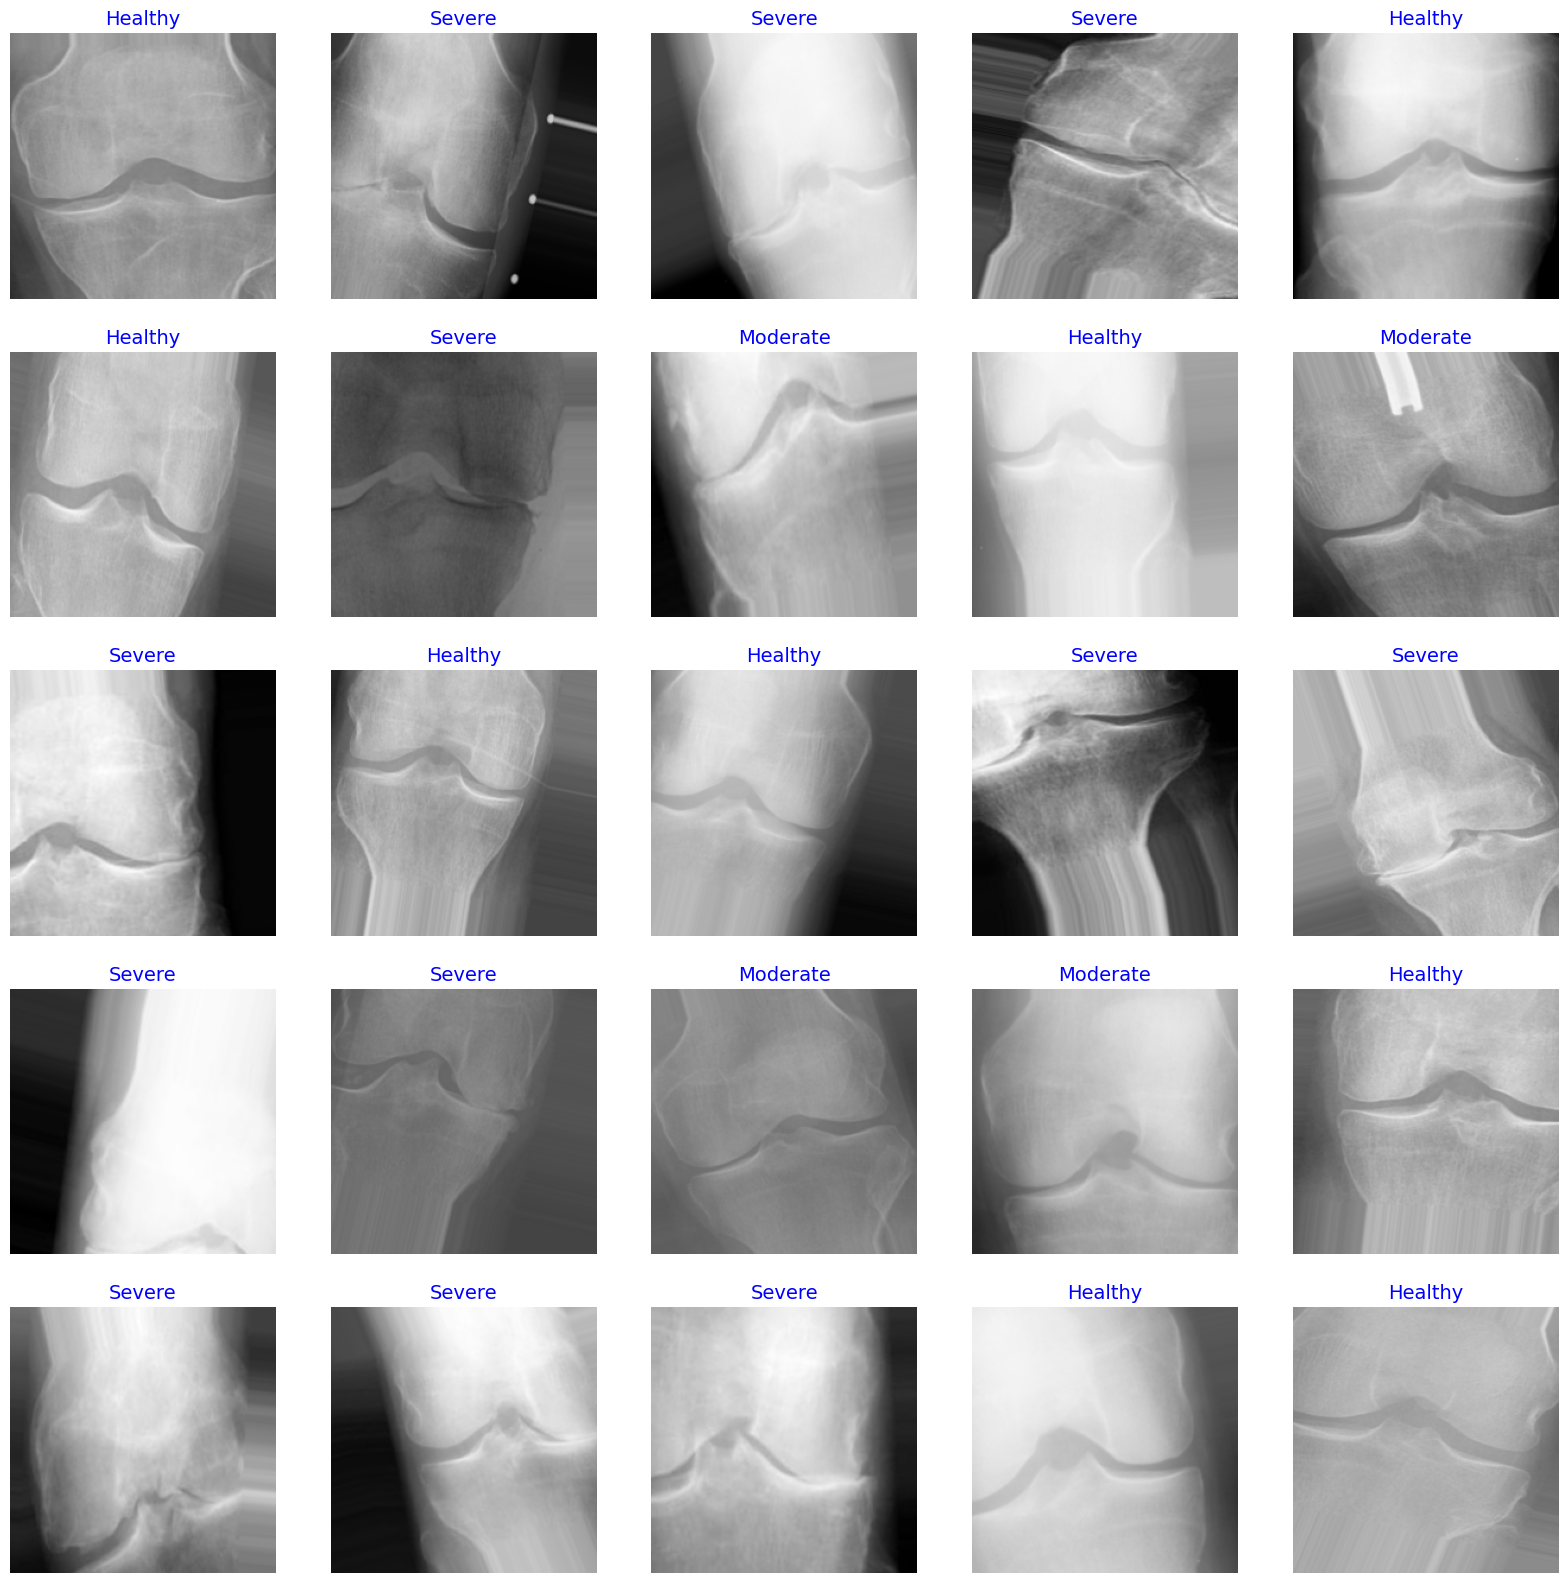

In [10]:
def show_image_samples(gen ):
    t_dict=gen.class_indices
    classes=list(t_dict.keys())    
    images,labels=next(gen) # get a sample batch from the generator 
    plt.figure(figsize=(20, 20))
    length=len(labels)
    if length<25:   #show maximum of 25 images
        r=length
    else:
        r=25
    for i in range(r):        
        plt.subplot(5, 5, i + 1)
        image=images[i] /255       
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color='blue', fontsize=14)
        plt.axis('off')
    plt.show()
    
show_image_samples(train_gen )

In [11]:
# Build the model
base_model = efficientnet.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling=None)
x = base_model.output
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.5)(x)
output = keras.layers.Dense(class_count, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])



I0000 00:00:1755451912.983477      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
import tensorflow as tf


class LR_ASK(tf.keras.callbacks.Callback):
    def __init__(self, epochs, ask_epoch):
        super(LR_ASK, self).__init__()
        self.ask_epoch = ask_epoch
        self.epochs = epochs

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.ask_epoch == 0:
            lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
            print(f"\n[LR_ASK] Epoch {epoch+1}/{self.epochs}, Current LR: {lr}")
            # you can also modify LR here if you want



In [13]:
epochs = 40
ask_epoch = 5
callbacks = [LR_ASK(epochs, ask_epoch)]

history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=valid_gen,
    callbacks=callbacks,
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


I0000 00:00:1755451966.181751      61 service.cc:148] XLA service 0x7d852c003520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755451966.182605      61 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1755451970.303511      61 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1755451978.971630      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755451979.163164      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755451979.635890      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755451979.8427

 4/47 ━━━━━━━━━━━━━━━━━━━━ 12s 300ms/step - accuracy: 0.4284 - loss: 1.6240

E0000 00:00:1755452011.976072      62 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755452012.164591      62 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755452012.629177      62 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755452012.838592      62 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1755452013.198281      62 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

47/47 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.5480 - loss: 1.2938 - val_accuracy: 0.7416 - val_loss: 0.7339
Epoch 2/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 563ms/step - accuracy: 0.7568 - loss: 0.7529 - val_accuracy: 0.8643 - val_loss: 0.3747
Epoch 3/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 563ms/step - accuracy: 0.8098 - loss: 0.5101 - val_accuracy: 0.8723 - val_loss: 0.3302
Epoch 4/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 586ms/step - accuracy: 0.8342 - loss: 0.4884 - val_accuracy: 0.9266 - val_loss: 0.2147
Epoch 5/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.8810 - loss: 0.3404
[LR_ASK] Epoch 5/40, Current LR: 0.0010000000474974513
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 566ms/step - accuracy: 0.8809 - loss: 0.3401 - val_accuracy: 0.9399 - val_loss: 0.1944
Epoch 6/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 576ms/step - accuracy: 0.8893 - loss: 0.2986 - val_accuracy: 0.9325 - val_loss: 0.2371
Epoch 7/40
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 566ms/step - accuracy: 0.8950 - loss: 0.2675 - val_accuracy: 0.9333

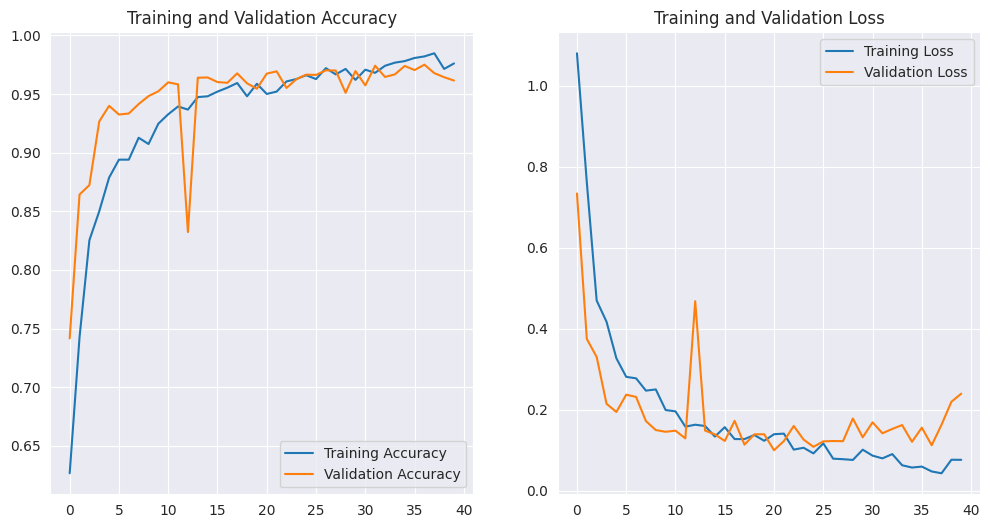

In [14]:
# Plot training and validation metrics
def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig('training_plot.png')
    plt.show()

plot_training(history)

In [15]:
# Evaluate on test set
test_steps = len(test_df) // batch_size
test_loss, test_accuracy = model.evaluate(test_gen, steps=test_steps, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.9893 - loss: 0.0597
Test accuracy: 0.9649, Test loss: 0.2098


144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 111ms/step


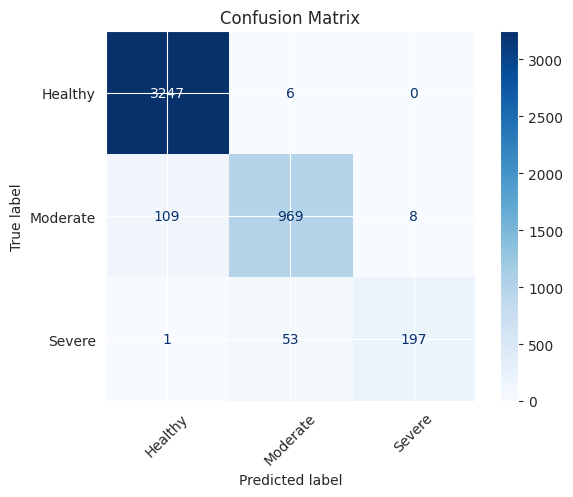

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions on validation set
y_true = valid_gen.classes                       # True labels
y_pred = model.predict(valid_gen)                # Predictions
y_pred_classes = np.argmax(y_pred, axis=1)       # Convert to class indices

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(valid_gen.class_indices.keys()))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [17]:
import numpy as np
from sklearn.metrics import classification_report

# Get predictions on validation set
y_true = valid_gen.classes
y_pred = model.predict(valid_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate classification report
target_names = list(valid_gen.class_indices.keys())
report = classification_report(y_true, y_pred_classes, target_names=target_names, digits=4)

print("Classification Report:")
print(report)


144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step
Classification Report:
              precision    recall  f1-score   support

     Healthy     0.9672    0.9982    0.9825      3253
    Moderate     0.9426    0.8923    0.9167      1086
      Severe     0.9610    0.7849    0.8640       251

    accuracy                         0.9614      4590
   macro avg     0.9569    0.8918    0.9211      4590
weighted avg     0.9611    0.9614    0.9604      4590



144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step


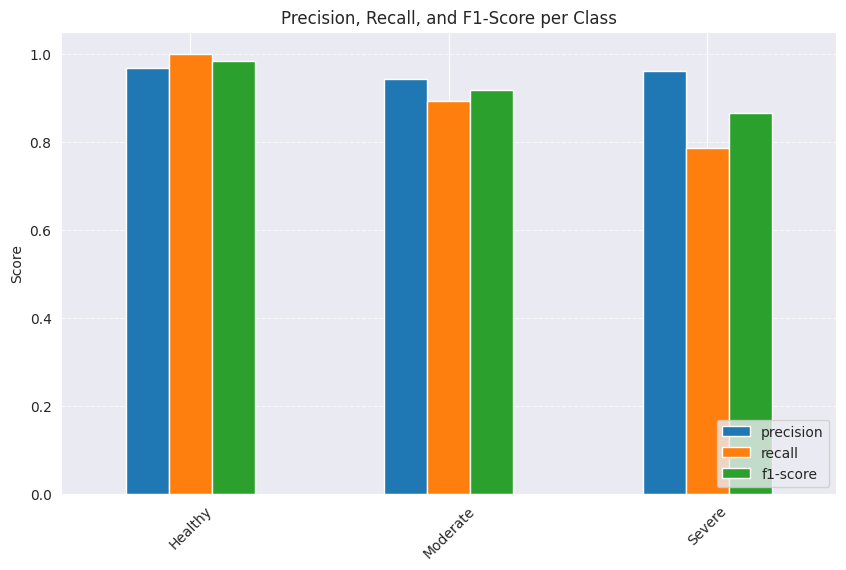

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd

# Get predictions on validation set
y_true = valid_gen.classes
y_pred = model.predict(valid_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate classification report as dictionary
target_names = list(valid_gen.class_indices.keys())
report_dict = classification_report(y_true, y_pred_classes, target_names=target_names, output_dict=True)

# Convert to DataFrame for easy plotting
df_report = pd.DataFrame(report_dict).transpose()

# Drop "accuracy", "macro avg", "weighted avg" for per-class plotting
df_plot = df_report.drop(["accuracy", "macro avg", "weighted avg"])

# Plot precision, recall, F1
ax = df_plot[["precision", "recall", "f1-score"]].plot(kind="bar", figsize=(10,6))
plt.title("Precision, Recall, and F1-Score per Class")
plt.ylabel("Score")
plt.ylim(0, 1.05)  # scores between 0 and 1
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step


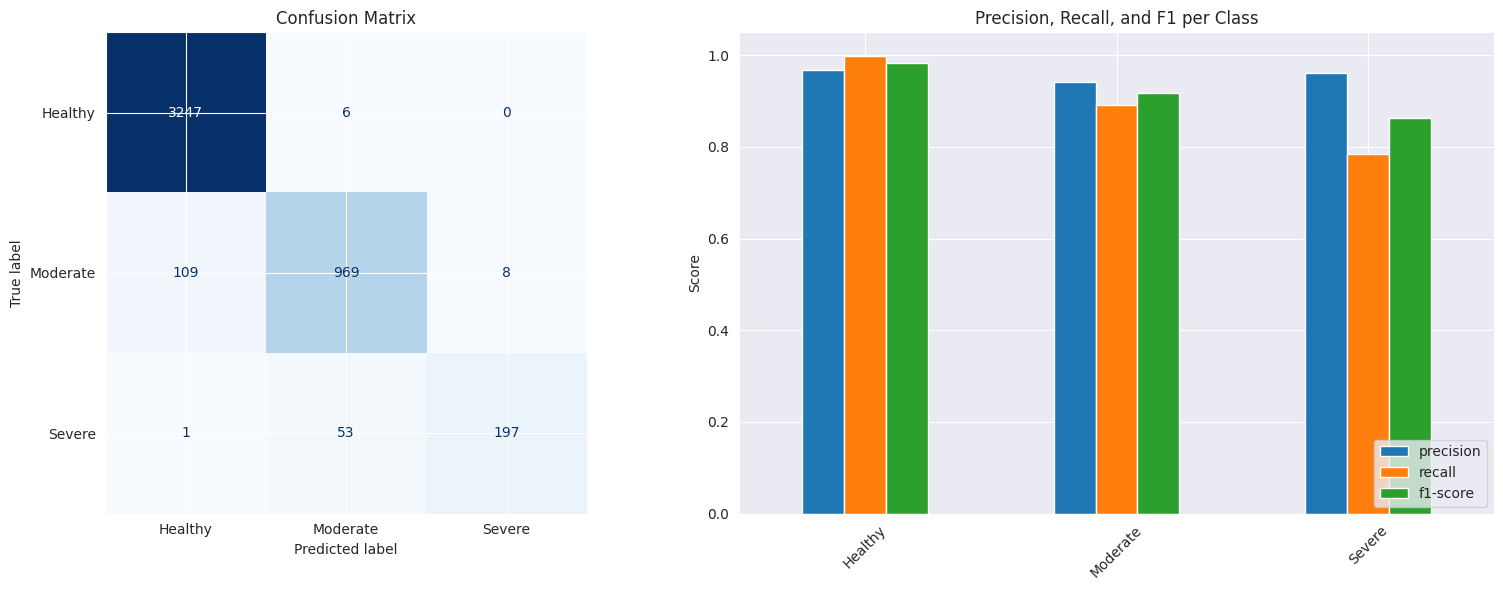

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd

# ----- Predictions -----
y_true = valid_gen.classes
y_pred = model.predict(valid_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

# ----- Confusion Matrix -----
cm = confusion_matrix(y_true, y_pred_classes)
class_names = list(valid_gen.class_indices.keys())

# ----- Classification Report -----
report_dict = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_plot = df_report.drop(["accuracy", "macro avg", "weighted avg"])  # per-class only

# ----- Plot both together -----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# Right: Precision, Recall, F1 bar chart
df_plot[["precision", "recall", "f1-score"]].plot(
    kind="bar",
    ax=axes[1],
    ylim=(0, 1.05),
    rot=45,
    grid=True
)
axes[1].set_title("Precision, Recall, and F1 per Class")
axes[1].set_ylabel("Score")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()
